# WEATHER TREND FORECASTING - PM ACCELERATOR ASSESSMENT
## Valeria Mora

In [1]:
import pandas as pd           # para manejar tablas de datos
import numpy as np            # para cálculos matemáticos
import matplotlib.pyplot as plt   # para hacer gráficas
import seaborn as sns         # gráficas más estéticas
import warnings
warnings.filterwarnings('ignore')  # ocultar advertencias menores

# Configurar el estilo de las gráficas
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Librerías cargadas correctamente")
print("Versiones instaladas:")
print(f"  pandas: {pd.__version__}")
print(f"  numpy: {np.__version__}")

✅ Librerías cargadas correctamente
Versiones instaladas:
  pandas: 3.0.3
  numpy: 2.4.4


In [2]:
# Cargar el dataset (archivo de datos)
# pd.read_csv() lee el archivo CSV y lo convierte en un DataFrame (tabla)
df = pd.read_csv('GlobalWeatherRepository.csv')

# Ver las primeras 5 filas para entender cómo se ve la tabla
print("Primeras 5 filas del dataset:")
print(df.head())

print(f"\nTamaño del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nNombres de todas las columnas:")
for col in df.columns:
    print(f"  • {col}")

Primeras 5 filas del dataset:
       country     location_name  latitude  longitude        timezone  \
0  Afghanistan             Kabul     34.52      69.18      Asia/Kabul   
1      Albania            Tirana     41.33      19.82   Europe/Tirane   
2      Algeria           Algiers     36.76       3.05  Africa/Algiers   
3      Andorra  Andorra La Vella     42.50       1.52  Europe/Andorra   
4       Angola            Luanda     -8.84      13.23   Africa/Luanda   

   last_updated_epoch      last_updated  temperature_celsius  \
0          1715849100  2024-05-16 13:15                 26.6   
1          1715849100  2024-05-16 10:45                 19.0   
2          1715849100  2024-05-16 09:45                 23.0   
3          1715849100  2024-05-16 10:45                  6.3   
4          1715849100  2024-05-16 09:45                 26.0   

   temperature_fahrenheit condition_text  ...  air_quality_PM2.5  \
0                    79.8  Partly Cloudy  ...                8.4   
1         

In [3]:
# ============================================================
# LIMPIEZA DE DATOS (Data Cleaning)
# ============================================================

# Ver información general del dataset
print("="*60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*60)
df.info()

# Ver cuántos valores faltantes hay en cada columna
# Un valor faltante (NaN) es una celda vacía en la tabla
print("\n" + "="*60)
print("VALORES FALTANTES POR COLUMNA")
print("="*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Valores Faltantes': missing, 
    'Porcentaje (%)': missing_pct
})
# Mostrar solo las columnas que tienen valores faltantes
cols_con_faltantes = missing_df[missing_df['Valores Faltantes'] > 0]
if len(cols_con_faltantes) > 0:
    print(cols_con_faltantes)
else:
    print("¡El dataset no tiene valores faltantes!")

# Estadísticas básicas de las columnas numéricas
print("\n" + "="*60)
print("ESTADÍSTICAS BÁSICAS")
print("="*60)
print(df.describe().round(2))

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 140923 entries, 0 to 140922
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       140923 non-null  str    
 1   location_name                 140923 non-null  str    
 2   latitude                      140923 non-null  float64
 3   longitude                     140923 non-null  float64
 4   timezone                      140923 non-null  str    
 5   last_updated_epoch            140923 non-null  int64  
 6   last_updated                  140923 non-null  str    
 7   temperature_celsius           140923 non-null  float64
 8   temperature_fahrenheit        140923 non-null  float64
 9   condition_text                140923 non-null  str    
 10  wind_mph                      140923 non-null  float64
 11  wind_kph                      140923 non-null  float64
 12  wind_degree            

In [4]:
# ============================================================
# PREPROCESAMIENTO DE DATOS
# ============================================================

# Convertir la columna de fecha al formato de fecha de Python
# (antes es texto, ahora será un objeto fecha real)
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Extraer componentes de la fecha (útiles para el análisis)
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
df['day_of_year'] = df['last_updated'].dt.day_of_year
df['month_name'] = df['last_updated'].dt.strftime('%B')

# Rellenar valores faltantes en columnas numéricas con la MEDIANA
# La mediana es el valor del medio (más robusta que el promedio)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Verificar que no queden valores faltantes
remaining_missing = df.isnull().sum().sum()
print(f"✅ Datos limpios y preparados")
print(f"   Valores faltantes restantes: {remaining_missing}")
print(f"   Filas totales: {len(df)}")
print(f"   Rango de fechas: {df['last_updated'].min().date()} → {df['last_updated'].max().date()}")
print(f"   Temperatura: min={df['temperature_celsius'].min():.1f}°C, max={df['temperature_celsius'].max():.1f}°C")

✅ Datos limpios y preparados
   Valores faltantes restantes: 0
   Filas totales: 140923
   Rango de fechas: 2024-05-16 → 2026-05-12
   Temperatura: min=-29.8°C, max=79.3°C


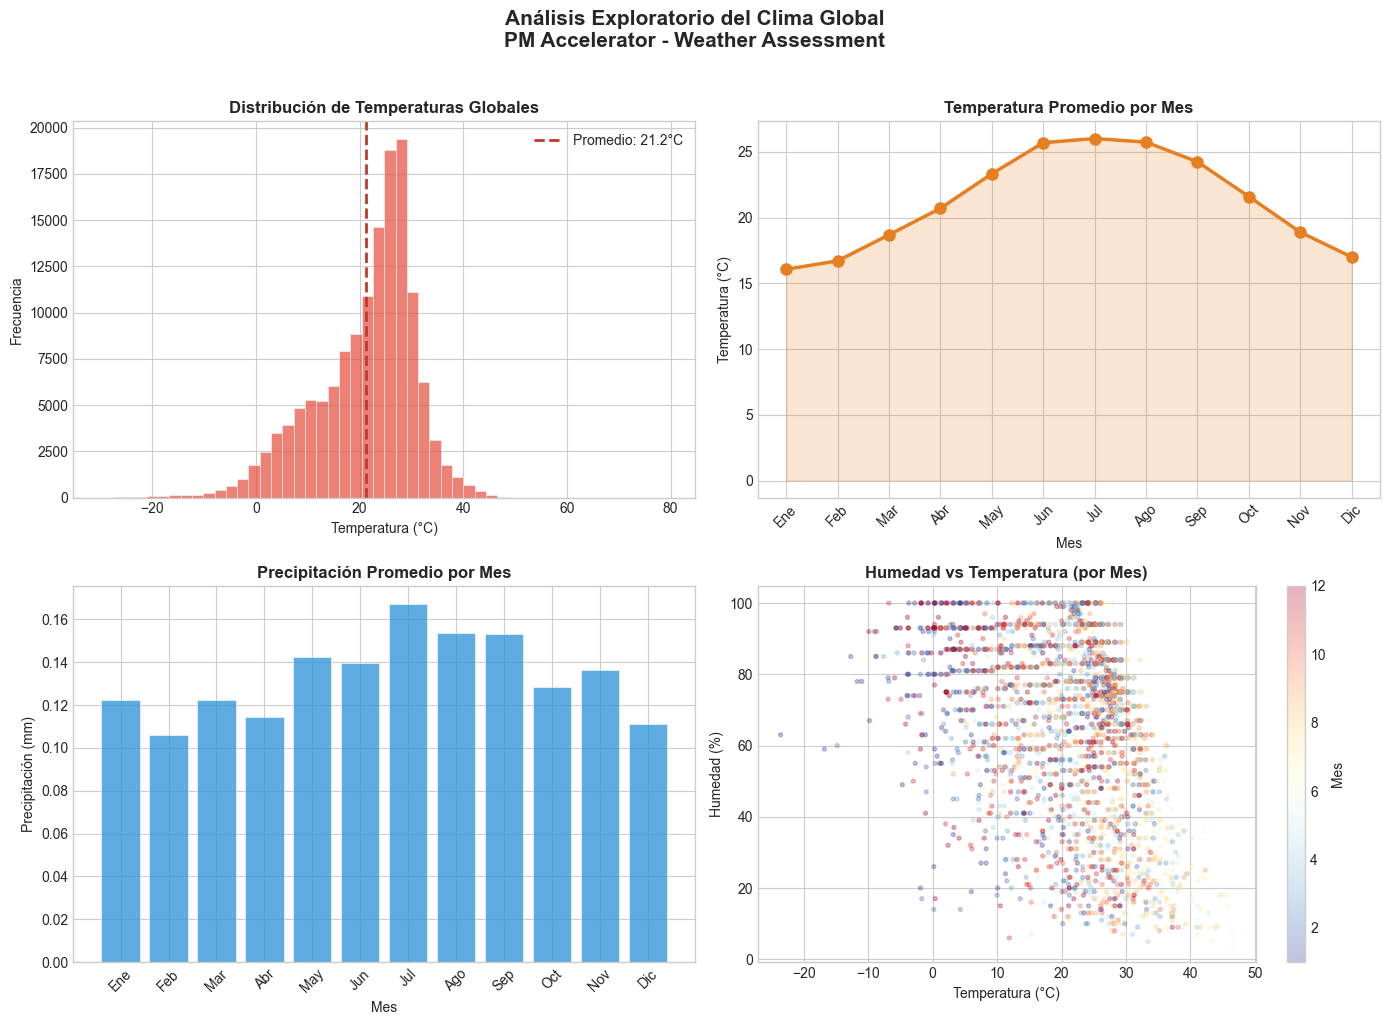

✅ Gráfica EDA guardada como 'eda_weather.png'


In [5]:
# ============================================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Exploratorio del Clima Global\nPM Accelerator - Weather Assessment', 
             fontsize=15, fontweight='bold', y=1.02)

# --- GRÁFICA 1: Distribución de temperaturas ---
axes[0,0].hist(df['temperature_celsius'], bins=50, 
               color='#e74c3c', alpha=0.7, edgecolor='white', linewidth=0.5)
axes[0,0].set_title('Distribución de Temperaturas Globales', fontweight='bold')
axes[0,0].set_xlabel('Temperatura (°C)')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].axvline(df['temperature_celsius'].mean(), color='#c0392b', 
                   linestyle='--', linewidth=2, label=f"Promedio: {df['temperature_celsius'].mean():.1f}°C")
axes[0,0].legend()

# --- GRÁFICA 2: Temperatura promedio por mes ---
temp_monthly = df.groupby('month')['temperature_celsius'].mean()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
axes[0,1].plot(temp_monthly.index, temp_monthly.values, 
               marker='o', color='#e67e22', linewidth=2.5, markersize=8)
axes[0,1].fill_between(temp_monthly.index, temp_monthly.values, alpha=0.2, color='#e67e22')
axes[0,1].set_title('Temperatura Promedio por Mes', fontweight='bold')
axes[0,1].set_xlabel('Mes')
axes[0,1].set_ylabel('Temperatura (°C)')
axes[0,1].set_xticks(range(1, 13))
axes[0,1].set_xticklabels(meses, rotation=45)

# --- GRÁFICA 3: Precipitación promedio por mes ---
precip_monthly = df.groupby('month')['precip_mm'].mean()
bars = axes[1,0].bar(precip_monthly.index, precip_monthly.values, 
                      color='#3498db', alpha=0.8, edgecolor='white', linewidth=0.5)
axes[1,0].set_title('Precipitación Promedio por Mes', fontweight='bold')
axes[1,0].set_xlabel('Mes')
axes[1,0].set_ylabel('Precipitación (mm)')
axes[1,0].set_xticks(range(1, 13))
axes[1,0].set_xticklabels(meses, rotation=45)

# --- GRÁFICA 4: Humedad vs Temperatura ---
sample = df.sample(min(3000, len(df)), random_state=42)
scatter = axes[1,1].scatter(sample['temperature_celsius'], sample['humidity'], 
                             alpha=0.3, s=8, c=sample['month'], cmap='RdYlBu_r')
axes[1,1].set_title('Humedad vs Temperatura (por Mes)', fontweight='bold')
axes[1,1].set_xlabel('Temperatura (°C)')
axes[1,1].set_ylabel('Humedad (%)')
plt.colorbar(scatter, ax=axes[1,1], label='Mes')

plt.tight_layout()
plt.savefig('eda_weather.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica EDA guardada como 'eda_weather.png'")

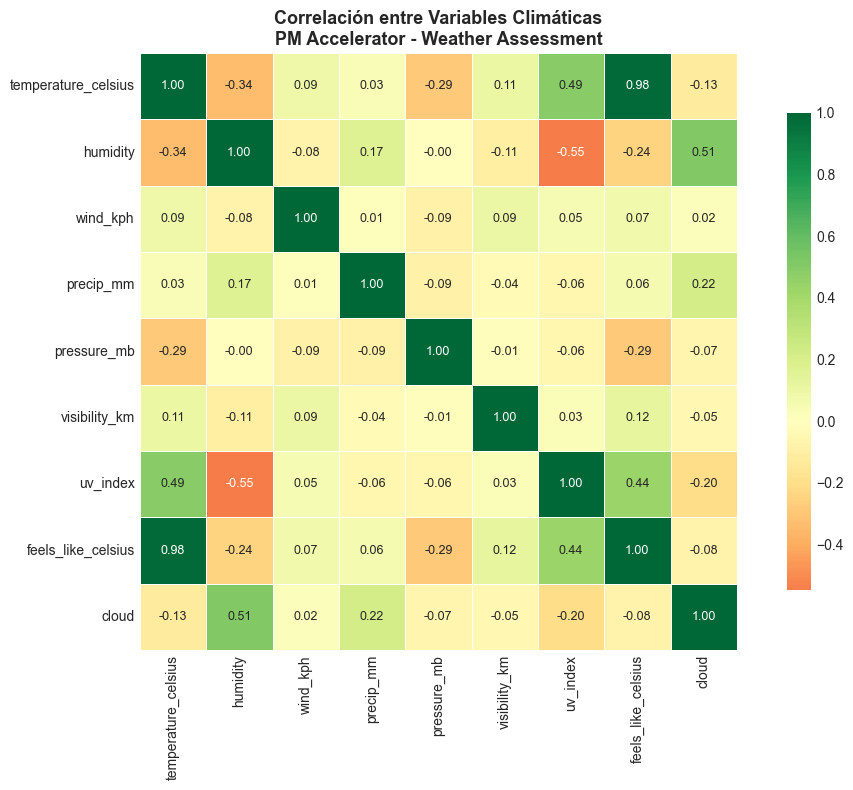


Correlaciones más fuertes con la temperatura:
  ↑ feels_like_celsius: 0.984
  ↑ uv_index: 0.490
  ↓ humidity: -0.339
  ↓ pressure_mb: -0.288
  ↓ cloud: -0.129
  ↑ visibility_km: 0.109
  ↑ wind_kph: 0.091
  ↑ precip_mm: 0.034

✅ Mapa de correlaciones guardado


In [6]:
# ============================================================
# MAPA DE CORRELACIÓN
# ============================================================
# La correlación mide qué tan relacionadas están dos variables
# Valor 1.0  = perfectamente relacionadas (si sube una, sube la otra)
# Valor -1.0 = inversamente relacionadas (si sube una, baja la otra)
# Valor 0.0  = no hay relación

# Seleccionar las columnas numéricas más relevantes
cols_correlacion = [
    'temperature_celsius', 'humidity', 'wind_kph', 
    'precip_mm', 'pressure_mb', 'visibility_km', 
    'uv_index', 'feels_like_celsius', 'cloud'
]
# Filtrar solo las columnas que existen en el dataset
cols_disponibles = [c for c in cols_correlacion if c in df.columns]

correlation_matrix = df[cols_disponibles].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='RdYlGn',
    center=0, 
    square=True, 
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9}
)
plt.title('Correlación entre Variables Climáticas\nPM Accelerator - Weather Assessment', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion_clima.png', dpi=150, bbox_inches='tight')
plt.show()

# Mostrar las correlaciones más fuertes con la temperatura
print("\nCorrelaciones más fuertes con la temperatura:")
temp_corr = correlation_matrix['temperature_celsius'].abs().sort_values(ascending=False)
for col, val in temp_corr.items():
    if col != 'temperature_celsius':
        direccion = "↑" if correlation_matrix['temperature_celsius'][col] > 0 else "↓"
        print(f"  {direccion} {col}: {correlation_matrix['temperature_celsius'][col]:.3f}")

print("\n✅ Mapa de correlaciones guardado")

In [7]:
# ============================================================
# MODELOS DE PREDICCIÓN (Machine Learning)
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Preparar los datos para el modelo ---

# Variables de entrada (X) = características que usamos para predecir
# Variable objetivo (y) = lo que queremos predecir (temperatura)
features = ['humidity', 'wind_kph', 'precip_mm', 'pressure_mb', 
            'visibility_km', 'uv_index', 'month', 'day_of_year']

# Filtrar solo las features que existen en el dataset
features_disponibles = [f for f in features if f in df.columns]
target = 'temperature_celsius'

# Eliminar filas con valores vacíos en estas columnas
model_df = df[features_disponibles + [target]].dropna()

X = model_df[features_disponibles]
y = model_df[target]

print(f"Variables de entrada (X): {features_disponibles}")
print(f"Variable objetivo (y): {target}")
print(f"\nDatos disponibles para el modelo: {len(model_df)} registros")

# --- Dividir los datos: 80% entrenar, 20% probar ---
# (Como estudiar con el 80% del libro y examinarte con el 20% restante)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nDatos de entrenamiento: {len(X_train)} registros (80%)")
print(f"Datos de prueba: {len(X_test)} registros (20%)")

# Normalizar los datos (poner todas las variables en la misma escala)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- MODELO 1: Regresión Lineal ---
# El más simple: busca una línea recta que relacione las variables con la temperatura
print("\n🔄 Entrenando Regresión Lineal...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print("✅ Regresión Lineal entrenada")

# --- MODELO 2: Random Forest ---
# Crea muchos "árboles de decisión" y promedia sus resultados
# Es más poderoso que la regresión lineal
print("\n🔄 Entrenando Random Forest (puede tardar 1-2 minutos)...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)  # Random Forest no necesita normalización
rf_pred = rf_model.predict(X_test)
print("✅ Random Forest entrenado")

# --- EVALUAR LOS MODELOS ---
def evaluar_modelo(nombre, y_real, y_pred):
    """Calcula y muestra las métricas de evaluación del modelo"""
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    print(f"\n{'='*40}")
    print(f"📊 {nombre}")
    print(f"{'='*40}")
    print(f"  MAE  (Error Absoluto Medio):       {mae:.2f}°C")
    print(f"       → El modelo se equivoca en promedio {mae:.2f}°C")
    print(f"  RMSE (Raíz del Error Cuadrático):  {rmse:.2f}°C")
    print(f"       → Penaliza más los errores grandes")
    print(f"  R²   (Precisión del modelo):       {r2:.4f} ({r2*100:.1f}%)")
    print(f"       → El modelo explica el {r2*100:.1f}% de la variabilidad")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

print("\n" + "="*50)
print("RESULTADOS DE LOS MODELOS")
print("="*50)
metricas_lr = evaluar_modelo("Regresión Lineal", y_test, lr_pred)
metricas_rf = evaluar_modelo("Random Forest", y_test, rf_pred)

# Comparar los modelos
print(f"\n🏆 Mejor modelo: {'Random Forest' if metricas_rf['R2'] > metricas_lr['R2'] else 'Regresión Lineal'}")

Variables de entrada (X): ['humidity', 'wind_kph', 'precip_mm', 'pressure_mb', 'visibility_km', 'uv_index', 'month', 'day_of_year']
Variable objetivo (y): temperature_celsius

Datos disponibles para el modelo: 140923 registros

Datos de entrenamiento: 112738 registros (80%)
Datos de prueba: 28185 registros (20%)

🔄 Entrenando Regresión Lineal...
✅ Regresión Lineal entrenada

🔄 Entrenando Random Forest (puede tardar 1-2 minutos)...
✅ Random Forest entrenado

RESULTADOS DE LOS MODELOS

📊 Regresión Lineal
  MAE  (Error Absoluto Medio):       6.04°C
       → El modelo se equivoca en promedio 6.04°C
  RMSE (Raíz del Error Cuadrático):  8.31°C
       → Penaliza más los errores grandes
  R²   (Precisión del modelo):       0.2563 (25.6%)
       → El modelo explica el 25.6% de la variabilidad

📊 Random Forest
  MAE  (Error Absoluto Medio):       3.00°C
       → El modelo se equivoca en promedio 3.00°C
  RMSE (Raíz del Error Cuadrático):  4.54°C
       → Penaliza más los errores grandes
  R²   (

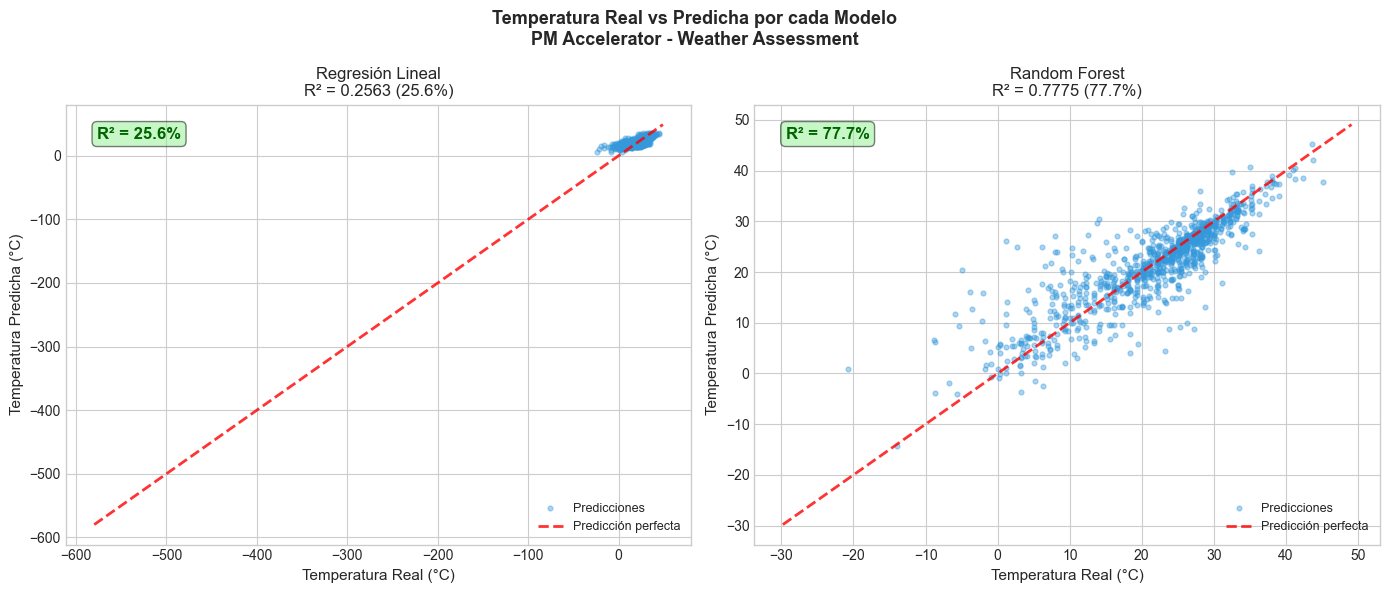

✅ Gráfica de predicciones guardada


In [8]:
# ============================================================
# GRÁFICAS DE EVALUACIÓN DE MODELOS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Temperatura Real vs Predicha por cada Modelo\nPM Accelerator - Weather Assessment', 
             fontsize=13, fontweight='bold')

for ax, nombre, pred, r2 in zip(
    axes,
    ['Regresión Lineal', 'Random Forest'],
    [lr_pred, rf_pred],
    [metricas_lr['R2'], metricas_rf['R2']]
):
    # Tomar una muestra para que la gráfica no sea tan densa
    muestra_idx = np.random.choice(len(y_test), min(1000, len(y_test)), replace=False)
    y_test_arr = np.array(y_test)
    
    ax.scatter(y_test_arr[muestra_idx], pred[muestra_idx], 
               alpha=0.4, s=12, color='#3498db', label='Predicciones')
    
    # Línea diagonal = predicción perfecta
    mn = min(y_test_arr.min(), pred.min())
    mx = max(y_test_arr.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Predicción perfecta', alpha=0.8)
    
    ax.set_xlabel('Temperatura Real (°C)', fontsize=11)
    ax.set_ylabel('Temperatura Predicha (°C)', fontsize=11)
    ax.set_title(f'{nombre}\nR² = {r2:.4f} ({r2*100:.1f}%)', fontsize=12)
    ax.legend(fontsize=9)
    ax.text(0.05, 0.95, f'R² = {r2*100:.1f}%', transform=ax.transAxes, 
            fontsize=12, fontweight='bold', color='darkgreen',
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig('predicciones_temperatura.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica de predicciones guardada")

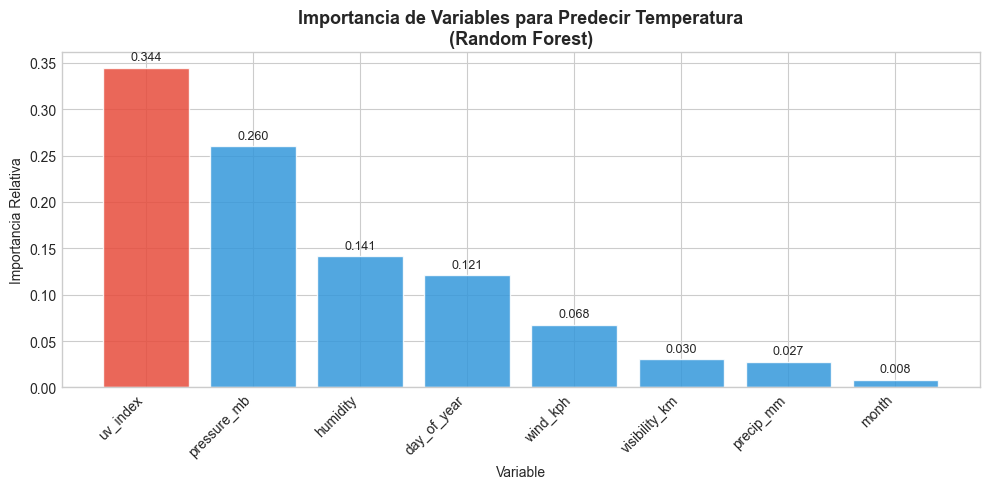


Ranking de importancia:
  1. uv_index: 0.3444 (34.4%)
  2. pressure_mb: 0.2599 (26.0%)
  3. humidity: 0.1414 (14.1%)
  4. day_of_year: 0.1208 (12.1%)
  5. wind_kph: 0.0677 (6.8%)
  6. visibility_km: 0.0303 (3.0%)
  7. precip_mm: 0.0273 (2.7%)
  8. month: 0.0082 (0.8%)

✅ Gráfica de importancia de variables guardada


In [9]:
# ============================================================
# IMPORTANCIA DE VARIABLES (Feature Importance)
# ============================================================
# El Random Forest puede decirnos qué variables son más importantes
# para predecir la temperatura

importances = rf_model.feature_importances_
feature_names = features_disponibles

# Ordenar de mayor a menor importancia
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(indices))]
bars = plt.bar(range(len(indices)), importances[indices], color=colors, alpha=0.85, edgecolor='white')
plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Importancia de Variables para Predecir Temperatura\n(Random Forest)', 
          fontsize=13, fontweight='bold')
plt.ylabel('Importancia Relativa')
plt.xlabel('Variable')

# Anotar los valores
for bar, imp in zip(bars, importances[indices]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{imp:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRanking de importancia:")
for i, idx in enumerate(indices):
    print(f"  {i+1}. {feature_names[idx]}: {importances[idx]:.4f} ({importances[idx]*100:.1f}%)")

print("\n✅ Gráfica de importancia de variables guardada")

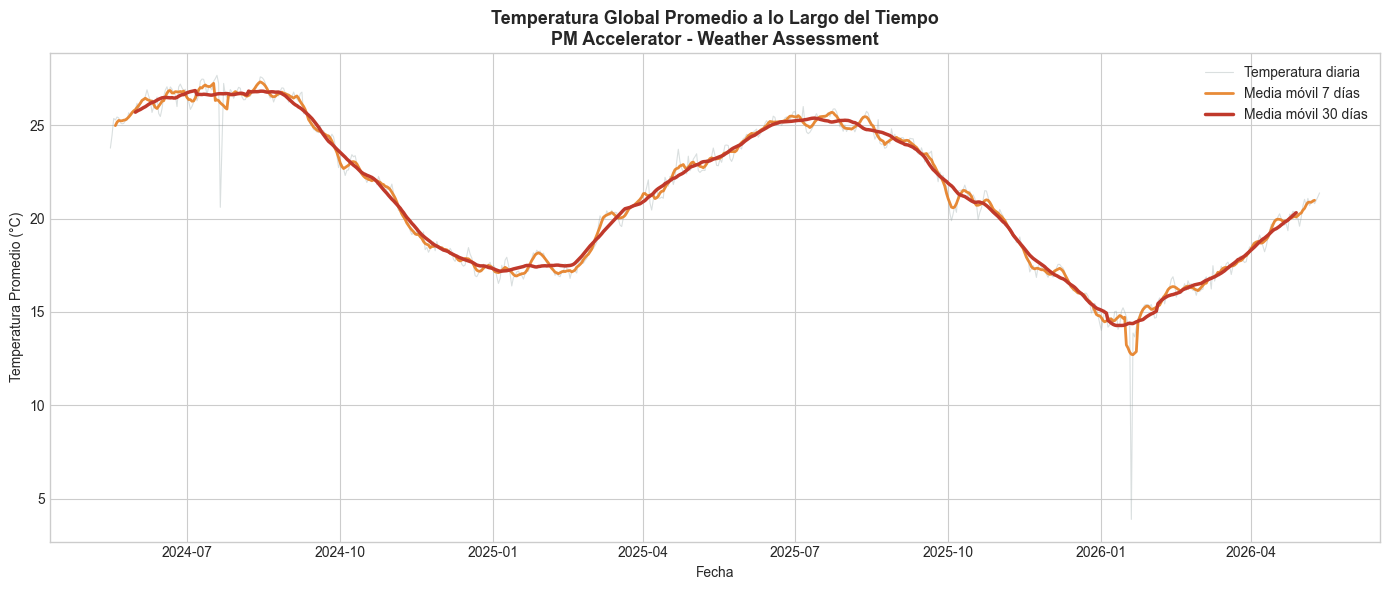

✅ Gráfica de series de tiempo guardada


In [10]:
# ============================================================
# ANÁLISIS DE SERIES DE TIEMPO (Time Series)
# ============================================================
# Una "serie de tiempo" = datos organizados por fecha
# Nos permite ver cómo cambia la temperatura a lo largo del tiempo

# Calcular la temperatura promedio por día
temp_daily = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean().reset_index()
temp_daily.columns = ['fecha', 'temperatura']
temp_daily['fecha'] = pd.to_datetime(temp_daily['fecha'])
temp_daily = temp_daily.sort_values('fecha')

# Calcular Media Móvil de 7 días
# (suaviza la línea para ver la tendencia sin tanto "ruido")
temp_daily['media_movil_7d'] = temp_daily['temperatura'].rolling(window=7, center=True).mean()
temp_daily['media_movil_30d'] = temp_daily['temperatura'].rolling(window=30, center=True).mean()

plt.figure(figsize=(14, 6))
plt.plot(temp_daily['fecha'], temp_daily['temperatura'], 
         alpha=0.35, color='#95a5a6', linewidth=0.8, label='Temperatura diaria')
plt.plot(temp_daily['fecha'], temp_daily['media_movil_7d'], 
         color='#e67e22', linewidth=2, label='Media móvil 7 días', alpha=0.9)
plt.plot(temp_daily['fecha'], temp_daily['media_movil_30d'], 
         color='#c0392b', linewidth=2.5, label='Media móvil 30 días')

plt.title('Temperatura Global Promedio a lo Largo del Tiempo\nPM Accelerator - Weather Assessment', 
          fontsize=13, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Temperatura Promedio (°C)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('serie_tiempo_temperatura.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica de series de tiempo guardada")

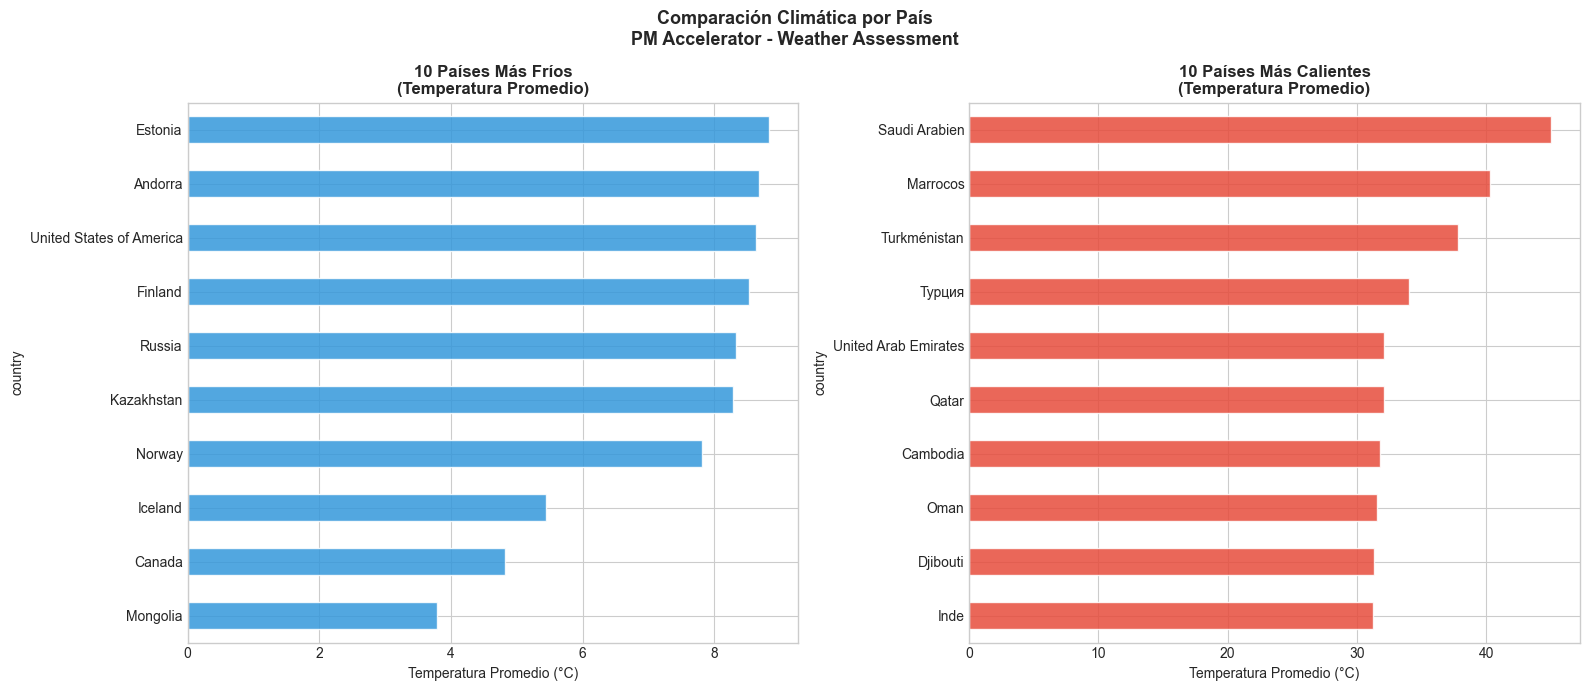

✅ Gráfica por países guardada

RESUMEN DEL PROYECTO - PM ACCELERATOR WEATHER ASSESSMENT

📍 Países analizados: 211
📅 Rango de fechas: 2024-05-16 → 2026-05-12
📊 Total de registros: 140,923

🌡️  Temperatura:
   Promedio global: 21.2°C
   Máxima registrada: 79.3°C
   Mínima registrada: -29.8°C

💧 Precipitación promedio: 0.1 mm
💨 Viento promedio: 12.9 km/h
💦 Humedad promedio: 66.7%

🤖 Rendimiento del mejor modelo (Random Forest):
   R² = 77.7% de precisión
   Error promedio = 3.00°C

✅ Análisis completo. Imágenes guardadas:
   • eda_weather.png
   • correlacion_clima.png
   • predicciones_temperatura.png
   • importancia_variables.png
   • serie_tiempo_temperatura.png
   • temperatura_por_pais.png


In [11]:
# ============================================================
# ANÁLISIS POR PAÍSES
# ============================================================

if 'country' in df.columns:
    temp_pais = df.groupby('country')['temperature_celsius'].mean().sort_values()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # 10 países más fríos
    temp_pais.head(10).plot(kind='barh', ax=axes[0], color='#3498db', alpha=0.85, edgecolor='white')
    axes[0].set_title('10 Países Más Fríos\n(Temperatura Promedio)', fontweight='bold')
    axes[0].set_xlabel('Temperatura Promedio (°C)')
    axes[0].axvline(0, color='black', linewidth=0.5)
    
    # 10 países más calientes
    temp_pais.tail(10).plot(kind='barh', ax=axes[1], color='#e74c3c', alpha=0.85, edgecolor='white')
    axes[1].set_title('10 Países Más Calientes\n(Temperatura Promedio)', fontweight='bold')
    axes[1].set_xlabel('Temperatura Promedio (°C)')
    
    plt.suptitle('Comparación Climática por País\nPM Accelerator - Weather Assessment', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('temperatura_por_pais.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Gráfica por países guardada")

# ============================================================
# RESUMEN FINAL
# ============================================================
print("\n" + "="*60)
print("RESUMEN DEL PROYECTO - PM ACCELERATOR WEATHER ASSESSMENT")
print("="*60)
if 'country' in df.columns:
    print(f"\n📍 Países analizados: {df['country'].nunique()}")
if 'city' in df.columns:
    print(f"🏙️  Ciudades analizadas: {df['city'].nunique()}")
print(f"📅 Rango de fechas: {df['last_updated'].min().date()} → {df['last_updated'].max().date()}")
print(f"📊 Total de registros: {len(df):,}")
print(f"\n🌡️  Temperatura:")
print(f"   Promedio global: {df['temperature_celsius'].mean():.1f}°C")
print(f"   Máxima registrada: {df['temperature_celsius'].max():.1f}°C")
print(f"   Mínima registrada: {df['temperature_celsius'].min():.1f}°C")
print(f"\n💧 Precipitación promedio: {df['precip_mm'].mean():.1f} mm")
print(f"💨 Viento promedio: {df['wind_kph'].mean():.1f} km/h")
print(f"💦 Humedad promedio: {df['humidity'].mean():.1f}%")
print(f"\n🤖 Rendimiento del mejor modelo (Random Forest):")
print(f"   R² = {metricas_rf['R2']*100:.1f}% de precisión")
print(f"   Error promedio = {metricas_rf['MAE']:.2f}°C")
print(f"\n✅ Análisis completo. Imágenes guardadas:")
print("   • eda_weather.png")
print("   • correlacion_clima.png")
print("   • predicciones_temperatura.png")
print("   • importancia_variables.png")
print("   • serie_tiempo_temperatura.png")
print("   • temperatura_por_pais.png")